Linear Regression:

Y = wX + b

Y --> Dependent Variable

X --> Independent Variable

w --> weight

b --> bias

Gradient Descent:

It is an optimization algorithm used for minimizing the loss function in various machine learning algorithms. it is used for updating the parameters of the learning model.

w = w - a*dw

b = b - a*db

Learning Rate:

It is a tuning parameter in an optimization algorithm that determines the step size of each iteration while moving toward a minimum of a loss function.

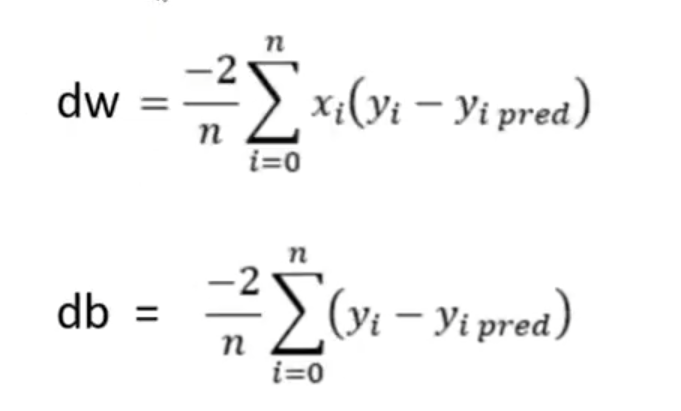

In [ ]:
#Importing numpy library
import numpy as np

Linear Regression

Step 1: Set Learning Rate and Number of Iterations; Initiate Random weight and bias value.

Step 2: Build Linear Regression Equation. (y = wx + b)

Step 3: Find the 'y pred' value for given x value for the corresponding weights and bias.

Step 4: Check the loss function for these parameter values. (difference between 'y pred' and 'true y'.

Step 5: Update the parameter values using Gradient Descent. (new weight and bias value)

Step 6:
Step 3, 4, 5 are repeated till we get minimum loss function.

Finally we will get the best model (best weight and bias value) as it has minimum loss function.

In [ ]:
class Linear_Regression():

  # initiating the paramters (learning rate and no. of iterations)
  def __init__(self, learning_rate, no_of_iterations):

    self.learning_rate = learning_rate
    self.no_of_iterations = no_of_iterations

  def fit(self, X, Y):

    # no. of training examples and no. of features

    self.m, self.n = X.shape # number of rows and columns

    # initiating the weight and bias

    self.w = np.zeros(self.n) # creating a matrix or array of weights with n number of columns and all values are 0 in it
    self.b = 0 # initiate the bias as 0 (weight can be a matrix or an array but bias should be a single value)
    self.X = X
    self.Y = Y

    # implementing gradient descent for optimization

    for i in range(self.no_of_iterations): # for loop to perform the no. of iterations that we will mention
      self.update_weights() # it is used to update the weights the no. of times the for loop will run

  def update_weights(self):

    Y_prediction = self.predict(self.X)

    # calculate the gradient

    dw = - (2 * (self.X.T).dot(self.Y - Y_prediction)) / self.m # derivative of the weight
    db = - 2 * np.sum(self.Y - Y_prediction) / self.m

    # updating the weights

    self.w = self.w - self.learning_rate * dw
    self.b = self.b - self.learning_rate * db

  def predict(self, X): # predicting the output salary using the X paramter which is the no. of years of experience used to find the expected salary as the output

    return X.dot(self.w) + self.b # dot is used for the dot product. dot product is used becuase it is a n array

Using Linear Regression Model for Prediction

In [ ]:
# importing the dependencies
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

Data Pre-Processing

In [ ]:
# loading the data from csv file to pandas dataframe

salary_data = pd.read_csv('/content/salary_data.csv')

In [ ]:
# printing the first five columns of the dataframe
salary_data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [ ]:
# printing the last 5 rows of the dataframe
salary_data.tail()

,YearsExperience,Salary
25,9.0,105582
26,9.5,116969
27,9.6,112635
28,10.3,122391
29,10.5,121872


In [ ]:
# print the number of rows and columns in the dataframe
salary_data.shape

(30, 2)

In [ ]:
# checking for missing values
salary_data.isnull().sum()

,0
YearsExperience,0
Salary,0


Splitting the fetaure and target

In [ ]:
X = salary_data.iloc[:, :-1].values # separating the last column of salary and storing only years of experience column
Y = salary_data.iloc[:,1].values #storing the salary column here

In [ ]:
print(X)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]


In [ ]:
print(Y)

[ 39343  46205  37731  43525  39891  56642  60150  54445  64445  57189
  63218  55794  56957  57081  61111  67938  66029  83088  81363  93940
  91738  98273 101302 113812 109431 105582 116969 112635 122391 121872]


Splitting the dataset into training and testing data

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.33, random_state = 2)

Training the Linear Regression Model

In [ ]:
model = Linear_Regression(learning_rate = 0.02, no_of_iterations = 1000)

In [ ]:
model.fit(X_train, Y_train)

In [ ]:
# printing the parameters values (weights and bias)

print('weight = ', model.w[0])
print('bias =', model.b)

weight =  9514.400999035135
bias = 23697.406507136307


y = 9514(x) + 23697

            or

salary = 9514(experience) + 23697

Predict the salary value for the test data

In [ ]:
test_data_prediction = model.predict(X_test)

In [ ]:
print(test_data_prediction)

[ 36066.12780588  34163.24760607  66512.21100279  58900.69020357
  91249.65360029  80783.81250135 101715.49469922  52240.60950424
  42726.20850521  88395.33330058]


Visualizing the predicted values and the actual values

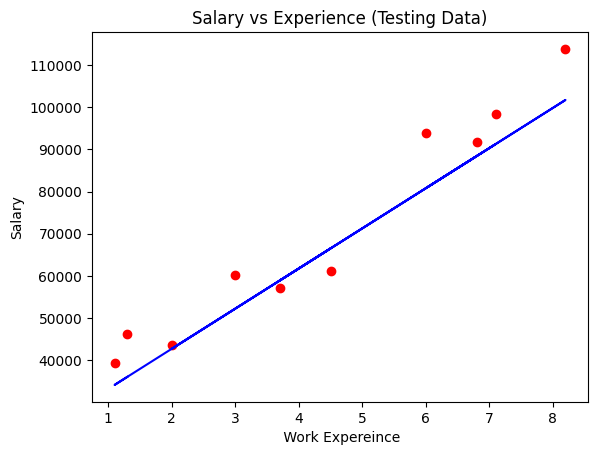

In [ ]:
plt.scatter(X_test, Y_test, color = 'red')
plt.plot(X_test, test_data_prediction, color = 'blue')
plt.xlabel(' Work Expereince')
plt.ylabel('Salary')
plt.title('Salary vs Experience (Testing Data)')
plt.show()